In [1]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scripts.train_model import circuit_training, train_five_times
from scr.qsvdd_core.data_loader import QuantumDataLoader
from scripts.test_model import test, mean_auc, best_batch, save_test_results

## Constants

In [2]:
dataset = 'fraud'
n_train = 0 ; latent_dim = 3
# num_params_conv = 375
cost_func = 'svdd'
learning_rate = 0.001

## Dataset

In [3]:
print("Current directory:", os.getcwd())
print("Files in this folder:", os.listdir())

Current directory: /home/jvfg/Documents/ORG/QSVDD2/notebooks
Files in this folder: ['training_test_data.ipynb', 'views.ipynb', 'circuit_visualization.ipynb', 'noise_data_visualization.ipynb', 'original_qcnn_experiments', 'training_test_data_with_pca.ipynb']


In [4]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset loaded successfully!\n")
print("First 5 records:\n", df.head())

Dataset loaded successfully!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.14126

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


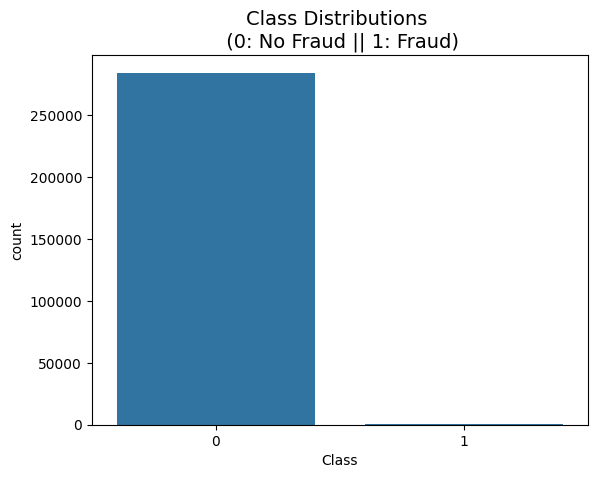

In [7]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [8]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [9]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [11]:
loader = QuantumDataLoader()

X_quantum, y = loader.prepare_fraud_data(df)

print(f"Features for the circuit: {X_quantum.shape}")
print(f"Labels: {y.shape}")

Features for the circuit: (284807, 32)
Labels: (284807,)


## Initial Training Setup

In [12]:
"""
One-class Training:
Separation into normal and fraudulent examples
QSVDD will learn what is normal.
"""
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# Train
# collect 1000 normal examples for training
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X_quantum[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

# X_train contains only legitimate transactions
X_train = X_train_normal
Y_train = y_train_normal

# Test (balanced)
# The code removes 100 normal examples that were not used in training
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X_quantum[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

# The code removes 100 fraud examples.
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X_quantum[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# creates a test set with 200 examples (50% normal, 50% fraud)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

center = np.zeros(latent_dim)
center_train = np.tile(center, (len(X_train), 1))

print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 32)
Y_train shape: (1000,)
X_test_normal shape: (100, 32)
X_test_abnormal shape: (100, 32)
X_test shape: (200, 32)
Y_test shape: (200,)
center_train shape: (1000, 3)


In [13]:
train_Xdata = X_train
train_Ydata = center_train

### Noiseless Training

#### QCNN Ansatz

In [14]:
qcnn_batch_size = 4
qcnn_steps = 100

In [ ]:
qcnn_start_time = time.time()
qcnn_loss_history, qcnn_est_params, qcnn_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qcnn_batch_size,
                     learning_rate=learning_rate,
                     steps=qcnn_steps,
                     ansatz='qcnn'
                     )
)
qcnn_end_time = time.time()

qcnn_total_runtime = (qcnn_end_time - qcnn_start_time) / 60
print(f"Total runtime: {qcnn_total_runtime} minutes for batch size {qcnn_batch_size}")

In [ ]:
qcnn_batch_list = [4, 8, 16, 32, 64]
qcnn_step_list = [2000, 1000, 500, 250, 125]

In [15]:
while qcnn_steps <= 1000:
    (qcnn_loss_history_matrix,
     qcnn_est_params_matrix,
     qcnn_param_history_matrix,
     qcnn_time_record) = train_five_times(X_train=train_Xdata,
                                            Y_train=train_Ydata,
                                            batch_size=qcnn_batch_size,
                                            learning_rate=learning_rate,
                                            steps=qcnn_steps,
                                            ansatz='qcnn'
                                            )
    f_name = f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_TIME_MEAN.npy"
    np.savetxt(f_name, qcnn_time_record)
    print(f"--- Training BATCH {qcnn_batch_size} STEPS {qcnn_steps} Completed ---")
    qcnn_steps = qcnn_steps + 50
print("--- All training batches completed ---")

--- Starting training round 1 with seed 2674222603 ---


/home/jvfg/Documents/ORG/QSVDD2/.venv/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:943: ComplexWarning: Casting complex values to real discards the imaginary part
  onp.add.at(A, idx, x)


--- Starting training round 2 with seed 18650737 ---
--- Starting training round 3 with seed 1884480906 ---
--- Starting training round 4 with seed 3868903782 ---
--- Starting training round 5 with seed 2362745472 ---
--- Training BATCH 4 STEPS 100 Completed ---
--- Starting training round 1 with seed 1098780197 ---
--- Starting training round 2 with seed 3352130930 ---
--- Starting training round 3 with seed 999377412 ---
--- Starting training round 4 with seed 3504419149 ---
--- Starting training round 5 with seed 2902450733 ---
--- Training BATCH 4 STEPS 150 Completed ---
--- Starting training round 1 with seed 3361318499 ---
--- Starting training round 2 with seed 3830258671 ---
--- Starting training round 3 with seed 2665143367 ---
--- Starting training round 4 with seed 1815172648 ---
--- Starting training round 5 with seed 502698867 ---
--- Training BATCH 4 STEPS 200 Completed ---
--- Starting training round 1 with seed 1471484572 ---
--- Starting training round 2 with seed 1673

#### QCNN Training Evaluation

In [ ]:
for i,batch in enumerate(qcnn_batch_list):
    qcnn_steps = qcnn_step_list[i]
    f_name = f"../results/training/QCNN/QCNN_B{batch:02d}S{qcnn_steps}_EST_PARAMS_MEAN.npy"
    params_list = np.loadtxt(f_name)
    mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=False, ansatz="qcnn")

    print(50*"--")
    print(f'for: B{batch}S{qcnn_steps} | AUC_mean: {mean} | std: {std}')
    print(50*"--")

#### Saving Noiseless Training with QCNN ansatz

In [ ]:
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_LOSS_HISTORY.npy", qcnn_loss_history)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_EST_PARAMS.npy", qcnn_est_params)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_PARAM_HISTORY.npy", qcnn_param_history)

#### QAE Ansatz

In [18]:
qae_batch_size = 16
qae_steps = 50

In [ ]:
qae_start_time = time.time()
qae_loss_history, qae_est_params, qae_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qae_batch_size,
                     learning_rate=learning_rate,
                     steps=qae_steps,
                     ansatz='qae'
                     )
)
qae_end_time = time.time()

qae_total_runtime = (qae_end_time - qae_start_time) / 60
print(f"Total runtime: {qae_total_runtime} minutes for batch size {qae_batch_size}")

In [ ]:
qae_batch_list = [16, 64]
qae_step_list = [2000, 2000]

In [19]:
while qae_steps <= 1000:
    (qae_loss_history_matrix,
     qae_est_params_matrix,
     qae_param_history_matrix,
     qae_time_record) = train_five_times(X_train=train_Xdata,
                                            Y_train=train_Ydata,
                                            batch_size=qae_batch_size,
                                            learning_rate=learning_rate,
                                            steps=qae_steps,
                                            ansatz='qae'
                                            )
    f_name = f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_TIME_MEAN.npy"
    np.savetxt(f_name, qae_time_record)
    print(f"--- Training BATCH {qae_batch_size} STEPS {qae_steps} Completed ---")
    qae_steps = qae_steps + 50
print("--- All training batches completed ---")

--- Starting training round 1 with seed 1319286814 ---
--- Starting training round 2 with seed 2509984641 ---
--- Starting training round 3 with seed 1535213403 ---
--- Starting training round 4 with seed 2370695541 ---
--- Starting training round 5 with seed 2965908525 ---
--- Training BATCH 16 STEPS 50 Completed ---
--- Starting training round 1 with seed 3058911495 ---
--- Starting training round 2 with seed 3168440243 ---
--- Starting training round 3 with seed 3028463174 ---
--- Starting training round 4 with seed 50230086 ---
--- Starting training round 5 with seed 2308691118 ---
--- Training BATCH 16 STEPS 100 Completed ---
--- Starting training round 1 with seed 3225955057 ---
--- Starting training round 2 with seed 2421356988 ---
--- Starting training round 3 with seed 719448397 ---
--- Starting training round 4 with seed 3693322677 ---
--- Starting training round 5 with seed 1355045075 ---
--- Training BATCH 16 STEPS 150 Completed ---
--- Starting training round 1 with seed 2

#### QAE Training Evaluation

In [ ]:
for i,batch in enumerate(qae_batch_list):
    qae_steps = qae_step_list[i]
    f_name = f"../results/training/QAE/QAE_B{batch:02d}S{qae_steps}_EST_PARAMS_MEAN.npy"
    params_list = np.loadtxt(f_name)
    mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=False, ansatz="qae")

    print(50*"--")
    print(f'for: B{batch}S{qae_steps} | AUC_mean: {mean} | std: {std}')
    print(50*"--")

#### Saving noiseless training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_LOSS_HISTORY.npy", qae_loss_history)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_EST_PARAMS.npy", qae_est_params)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_PARAM_HISTORY.npy", qae_param_history)

In [ ]:
f_name = f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_EST_PARAMS_MEAN.npy"
params_list = np.loadtxt(f_name)
mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=False, ansatz="qae")

print(f'mean: {mean} | std: {std}')

#### LCQHNN Ansatz

In [14]:
center = np.zeros(5)
center_train = np.tile(center, (len(X_train), 1))
lcqhnn_batch_size = 4
lcqhnn_steps = 100
print(f'center_train shape: {center_train.shape}')
train_Xdata = X_train
train_Ydata = center_train

center_train shape: (1000, 5)


In [ ]:
lcqhnn_start_time = time.time()
lcqhnn_loss_history, lcqhnn_est_params, lcqhnn_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=lcqhnn_batch_size,
                     learning_rate=learning_rate,
                     steps=lcqhnn_steps,
                     ansatz='lcqhnn'
                     )
)
lcqhnn_end_time = time.time()

lcqhnn_total_runtime = (lcqhnn_end_time - lcqhnn_start_time) / 60
print(f"Total runtime: {lcqhnn_total_runtime} minutes for batch size {lcqhnn_batch_size}")

In [ ]:
lcqhnn_batch_list = [4]

In [16]:
for i in range(20):
    (lcqhnn_loss_history_matrix,
     lcqhnn_est_params_matrix,
     lcqhnn_param_history_matrix,
     lcqhnn_time_record) = train_five_times(X_train=train_Xdata,
                                            Y_train=train_Ydata,
                                            batch_size=lcqhnn_batch_size,
                                            learning_rate=learning_rate,
                                            steps=lcqhnn_steps,
                                            ansatz='lcqhnn'
                                            )
    f_name = f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_TIME_MEAN.npy"
    np.savetxt(f_name, lcqhnn_time_record)
    print(f"--- Training BATCH {lcqhnn_batch_size} STEPS {lcqhnn_steps} Completed ---")
    lcqhnn_steps = lcqhnn_steps + 50
print("--- All training batches completed ---")

--- Starting training round 1 with seed 774181896 ---
iteration: 0 | cost: 0.137349
iteration: 1 | cost: 0.144056
iteration: 2 | cost: 0.140431
iteration: 3 | cost: 0.136527
iteration: 4 | cost: 0.129164
iteration: 5 | cost: 0.135507
iteration: 6 | cost: 0.137870
iteration: 7 | cost: 0.136559
iteration: 8 | cost: 0.132475
iteration: 9 | cost: 0.133920
iteration: 10 | cost: 0.135793
iteration: 11 | cost: 0.133228
iteration: 12 | cost: 0.132242
iteration: 13 | cost: 0.123258
iteration: 14 | cost: 0.128526
iteration: 15 | cost: 0.133997
iteration: 16 | cost: 0.129903
iteration: 17 | cost: 0.137303
iteration: 18 | cost: 0.139633
iteration: 19 | cost: 0.126907
iteration: 20 | cost: 0.135723
iteration: 21 | cost: 0.135839
iteration: 22 | cost: 0.127204
iteration: 23 | cost: 0.129782
iteration: 24 | cost: 0.125509
iteration: 25 | cost: 0.133150
iteration: 26 | cost: 0.129688
iteration: 27 | cost: 0.128708
iteration: 28 | cost: 0.136121
iteration: 29 | cost: 0.133855
iteration: 30 | cost: 0.13

#### LCQHNN Training Evaluation

In [ ]:
for i,batch in enumerate(lcqhnn_batch_list):
    f_name = f"../results/training/LCQHNN/LCQHNN_B{batch:02d}S{lcqhnn_steps}_EST_PARAMS_MEAN.npy"
    params_list = np.loadtxt(f_name)
    mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=False, ansatz="lcqhnn")

    print(50*"--")
    print(f'for: B{batch}S{lcqhnn_steps} | AUC_mean: {mean} | std: {std}')
    print(50*"--")

#### saving noiseless training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_LOSS_HISTORY.npy", lcqhnn_loss_history)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_EST_PARAMS.npy", lcqhnn_est_params)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_PARAM_HISTORY.npy", lcqhnn_param_history)

### Noisy Training

#### QCNN Ansatz noisy training

In [ ]:
qcnn_start_time_noise = time.time()
qcnn_loss_history_noise, qcnn_est_params_noise, qcnn_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qcnn_batch_size,
                     learning_rate=learning_rate,
                     steps=qcnn_steps,
                     noisy=True,
                     ansatz='qcnn'
                     )
)
qcnn_end_time_noise = time.time()

qcnn_total_runtime_noise = (qcnn_end_time_noise - qcnn_start_time_noise) / 60
print(f"Total runtime: {qcnn_total_runtime_noise} minutes for batch size {qcnn_batch_size}")

In [ ]:
qcnn_matrix_of_parameters = train_five_times(X_train=train_Xdata,
                                               Y_train=train_Ydata,
                                               batch_size=qcnn_batch_size,
                                               learning_rate=learning_rate,
                                               steps=qcnn_steps,
                                               noisy=True,
                                               ansatz='qcnn'
                                               )
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_EST_PARAMS_MEAN.npy",
           qcnn_matrix_of_parameters)
print("--- Training Completed ---")

In [ ]:
f_name = f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_EST_PARAMS_MEAN.npy"
params_list = np.loadtxt(f_name)
mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=True, ansatz="qcnn")

print(50*"--")
print(f'for: B{qcnn_batch_size}S{qcnn_steps} | AUC_mean: {mean} | std: {std}')
print(50*"--")

#### Saving QCNN ansatz Noisy Training

In [ ]:
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_LOSS_HISTORY.npy", qcnn_loss_history_noise)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_EST_PARAMS.npy", qcnn_est_params_noise)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_PARAM_HISTORY.npy", qcnn_param_history_noise)

#### QAE Ansatz noisy training

In [ ]:
qae_start_time_noise = time.time()
qae_loss_history_noise, qae_est_params_noise, qae_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qae_batch_size,
                     learning_rate=learning_rate,
                     steps=qae_steps,
                     noisy=True,
                     ansatz='qae'
                     )
)
qae_end_time_noise = time.time()

qae_total_runtime_noise = (qae_end_time_noise - qae_start_time_noise) / 60
print(f"Total runtime: {qae_total_runtime_noise} minutes for batch size {qae_batch_size}")

In [ ]:
qae_matrix_of_parameters = train_five_times(X_train=train_Xdata,
                                               Y_train=train_Ydata,
                                               batch_size=qae_batch_size,
                                               learning_rate=learning_rate,
                                               steps=qae_steps,
                                               noisy=True,
                                               ansatz='qae'
                                               )
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_EST_PARAMS_MEAN.npy",
           qae_matrix_of_parameters)
print("--- Training Completed ---")

In [ ]:
f_name = f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_EST_PARAMS_MEAN.npy"
params_list = np.loadtxt(f_name)
mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=True, ansatz="qae")

print(50*"--")
print(f'for: B{qae_batch_size}S{qae_steps} | AUC_mean: {mean} | std: {std}')
print(50*"--")

#### saving noisy training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_LOSS_HISTORY.npy", qae_loss_history_noise)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_EST_PARAMS.npy", qae_est_params_noise)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_PARAM_HISTORY.npy", qae_param_history_noise)

#### LCQHNN Ansatz noisy training

In [ ]:
lcqhnn_start_time_noise = time.time()
lcqhnn_loss_history_noise, lcqhnn_est_params_noise, lcqhnn_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=lcqhnn_batch_size,
                     learning_rate=learning_rate,
                     steps=lcqhnn_steps,
                     noisy=True,
                     ansatz='lcqhnn'
                     )
)
lcqhnn_end_time_noise = time.time()

lcqhnn_total_runtime_noise = (lcqhnn_end_time_noise - lcqhnn_start_time_noise) / 60
print(f"Total runtime: {lcqhnn_total_runtime_noise} minutes for batch size {lcqhnn_batch_size}")

In [ ]:
lcqhnn_matrix_of_parameters = train_five_times(X_train=train_Xdata,
                                               Y_train=train_Ydata,
                                               batch_size=lcqhnn_batch_size,
                                               learning_rate=learning_rate,
                                               steps=lcqhnn_steps,
                                               noisy=True,
                                               ansatz='lcqhnn'
                                               )
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_EST_PARAMS_MEAN.npy",
           lcqhnn_matrix_of_parameters)
print("--- Training Completed ---")

#### saving noisy training with LCQHNN Ansatz

In [ ]:
f_name = f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_EST_PARAMS_MEAN.npy"
params_list = np.loadtxt(f_name)
mean, std = mean_auc(params_list, n_train, X_test, Y_test, center_train, noisy=True, ansatz="lcqhnn")

print(50*"--")
print(f'for: B{lcqhnn_batch_size}S{lcqhnn_steps} | AUC_mean: {mean} | std: {std}')
print(50*"--")

In [ ]:
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_LOSS_HISTORY.npy", lcqhnn_loss_history_noise)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_EST_PARAMS.npy", lcqhnn_est_params_noise)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_PARAM_HISTORY.npy", lcqhnn_param_history_noise)

## Noiseless Test

#### QCNN Ansatz noiseless Test

#### defining best batch

In [ ]:
qcnn_test_best_batch = best_batch(method='qcnn')

In [ ]:
save_test_results(qcnn_test_best_batch, method='qcnn')

In [ ]:
best_qcnn = 'B04S2000'
f_name = f"../results/training/QCNN/QCNN_{best_qcnn}_EST_PARAMS.npy"
est_params = np.loadtxt(f_name)

auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, est_params, center_train, ansatz='qcnn')

#### QAE Ansatz noiseless Test

#### defining best batch

In [ ]:
qae_test_best_batch = best_batch(method='qae')

In [ ]:
save_test_results(qae_test_best_batch, method='qae')

In [ ]:
f_name = "../results/training/QAE/QAE_B04S2000_EST_PARAMS.npy"
qae_est_params = np.loadtxt(f_name)

auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, qae_est_params, center_train, ansatz='qae')

#### LCQHNN Ansatz noiseless Test

#### defining best batch

In [ ]:
lcqhnn_test_best_batch = best_batch(method='lcqhnn')

In [ ]:
save_test_results(lcqhnn_test_best_batch, method='lcqhnn')

## Saving Noiseless Test

In [ ]:
plt.hist(y_pred)

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="{:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Noisy Test

In [ ]:
auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, qae_est_params_noise, center_train, noisy=True)

## Saving Noisy Test

In [ ]:
file_name = f"B{qae_batch_size:02d}S{qae_steps}_NOISY.txt"
results_dir = os.path.join("..", "results", "test")
file_path = os.path.join(results_dir, file_name)

os.makedirs(results_dir, exist_ok=True)

with open(file_path, "w") as f:
    f.write("Test completed.\n")̣
    f.write(f"Batch Size = {qae_batch_size} \nSteps = {qae_steps} \n")
    f.write(f"Training time: {total_runtime:.2f} minutes\n")
    f.write(f"AUC: {auc:.4f}\n")

print(f"Success! Result saved to: {file_path}")
print(f"Training time: {total_runtime:.2f} minutes")
print(f"AUC Score: {auc:.4f}")

In [ ]:
plt.hist(y_pred)

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="AUC Score: {:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve noisy")
plt.legend(loc="lower right")
plt.show()